# Проект. Исследование стартапов

## Введение

В этом проекте исследуются данные 2015 года о финансировании стартапов. Цель исследования — подготовить данные к анализу, изучить динамику и структуру инвестиций, выявить закономерности и определить наиболее перспективные направления для вложений, если бы решение принималось в 2015 году.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Основной датасет содержит данные о компаниях и их раундах финансирования: суммы по разным типам инвестиций, даты раундов, статус компании, страна и регион, сегмент рынка и другие характеристики. Дополнительный датасет содержит суммы возвратов по типам финансирования в разбивке по годам.

### 1.1. Вывод общей информации

In [2]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix 

In [3]:
# Загружаем данные о состоявшемся финансировании
dfi = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [4]:
# Загружаем данные об объёмах возвратов, в файле рзделитель запятая
dfr = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv", sep=',', low_memory=False)

In [5]:
dfi.head(3)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
dfi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [7]:
# Проверим написание названий заголовков в dfi
dfi.columns.tolist()

['name',
 'homepage_url',
 'category_list',
 ' market ',
 ' funding_total_usd ',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'participants',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'mid_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_A',
 'round_B',
 'round_C',
 'round_D',
 'round_E',
 'round_F',
 'round_G',
 'round_H']

Названия столбцов dfi соответствуют змеиному регистру, в некоторых есть лишние пробелы, потребуется обработка.<br>
В датафрейме 54 294 строки и 40 столбцов.<br>
Во всех столбцах присутствуют пропущенные значения в разном количестве.<br>
Типы данных требуют корректировки:<br>
- funding_rounds, participants и founded_year необходимо привести к int64,<br>
- столбцы с датами — к datetime,<br>
- funding_total_usd — к float64.

In [8]:
dfr.head(10)

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.0,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.0,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.0,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.0,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.0,0.12,0.02


In [9]:
dfr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [10]:
dfr.columns.tolist()

['year',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding']

Названия столбцов датафрейма dfr тоже соответствуют змеиному регистру, лишних пробелов нет, обработка не требуется.<br>
В датафрейме 15 строк и 14 столбцов. Пропусков нет. Типы данных корректные.<br>

В двух датасетах есть колонки с одинаковыми названиями, это нужно будет учитывать при объединении данных в дальнейшем и избегать дефолтных суффиксов.

### 1.2. Предобработка данных

В датасете dfi были найдены лишние пробелы в названиях некоторых колонок.

In [11]:
# Удаляем лишний пробел в названиях колонок dfi
dfi.columns = dfi.columns.str.strip()

In [12]:
# Как сейчас отображаются данные в funding_total_usd
dfi['funding_total_usd'].head(3)

0     9,00,00,000 
1       20,00,000 
2       90,00,000 
Name: funding_total_usd, dtype: object

In [13]:
# Удаляем запятые и приводим к float64
dfi['funding_total_usd'] = pd.to_numeric(dfi['funding_total_usd'].str.replace(',', ''), errors='coerce').astype('float64')

In [14]:
# Как отображаются данные в funding_total_usd после преобразования
dfi['funding_total_usd'].head(3)

0    90000000.0
1     2000000.0
2     9000000.0
Name: funding_total_usd, dtype: float64

**founded_month и founded_quarter не преобразовываю**. При необходимости сможем месяц и квартал извлечь из преобразованного founded_at.

In [15]:
# Меняем типы данных в dfi на datetime, где это сразу возможно
dfi[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']] = (
    dfi[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']]
    .apply(pd.to_datetime, errors='coerce')
)

Меняем числовые типы данных.

In [16]:
# Меняем типы данных в dfi на числовые
dfi[['founded_year', 'participants', 'funding_rounds']] = (
    dfi[['founded_year', 'participants', 'funding_rounds']]
    .apply(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

In [17]:
# Мы уже привели funding_total_usd к типу float64 выше, но код мог выглядеть так
# dfi['funding_total_usd'] = pd.to_numeric(dfi['funding_total_usd'], errors='coerce').astype('float64')

In [18]:
# Делаем годы индексами для dfr
dfr = dfr.set_index('year')

In [19]:
# Посмотрим список тектовых колонок dfi с пропусками
dfi.select_dtypes(include='object').isna().sum()

name                4857
homepage_url        8305
category_list       8817
market              8817
status              6170
country_code       10129
state_code         24133
region             10129
city               10972
founded_month      15812
founded_quarter    15812
dtype: int64

Будем заполнять пропуски в колонках: category_list, market, status, country_code, state_code, region, city. Потому что в анализе они будут участвовать с большой вероятностью. Название и сайт не заполняю, потому что объединение большого числа таких компаний может сильно повлиять на анализ.

In [20]:
# Заполняем пропуски в необходимых текстовых столбцах
dfi[['market', 'status', 'country_code', 'state_code', 'region', 'city']]= (
dfi[['market', 'status', 'country_code', 'state_code', 'region', 'city']]
    .fillna('unknown')
)

# Или так: 
# text_cols = ['market', 'status', 'country_code', 'state_code', 'region', 'city']
# dfi[text_cols] = dfi[text_cols].fillna('unknown')

In [21]:
# Считаем полные дубликаты в dfi
dfi.duplicated().sum()

4855

In [22]:
# Считаем полные дубликаты в dfr
dfr.duplicated().sum()

0

Полные дубликаты есть только в dfi. 

In [23]:
# Удаяем полные дубликаты из dfi
dfi = dfi.drop_duplicates()

In [24]:
# Полные дубликаты удалены из dfi
dfi.duplicated().sum()

0

In [25]:
# Посчитаем пропуски в funding_total_usd
dfi['funding_total_usd'].isna().sum()

8532

In [26]:
# Посмотрим на информацию о пропусках
dfi[dfi['funding_total_usd'].isna()].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8532 entries, 13 to 49438
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  8531 non-null   object        
 1   homepage_url          7396 non-null   object        
 2   category_list         7073 non-null   object        
 3   market                8532 non-null   object        
 4   funding_total_usd     0 non-null      float64       
 5   status                8532 non-null   object        
 6   country_code          8532 non-null   object        
 7   state_code            8532 non-null   object        
 8   region                8532 non-null   object        
 9   city                  8532 non-null   object        
 10  funding_rounds        8531 non-null   Int64         
 11  participants          3142 non-null   Int64         
 12  founded_at            6353 non-null   datetime64[ns]
 13  founded_month   

Полностью пустых строк по этому столбцу нет. Заполнять такую важную колонку 0, средним или медианой — некорректно. Решено никак не обрабатывать эти пропуски.

Чтобы удалить все строки, которые не несут какой-либо информации либо не содержат данных о финансировании, снчала составим список колонок которые должны содержать такую информацию:

In [27]:
# Список колонок с информацией о финансировании проектов
funding_cols = [
    'funding_total_usd', 'funding_rounds', 'participants',
    'first_funding_at', 'mid_funding_at', 'last_funding_at',
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding',
    'round_A', 'round_B', 'round_C', 'round_D',
    'round_E', 'round_F', 'round_G', 'round_H'
]

In [28]:
# Смотрим, есть ли строки, где все эти столбцы пустые
dfi[dfi[funding_cols].isna().all(axis=1)]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
49438,NaN,NaN,NaN,unknown,NaN,unknown,unknown,unknown,unknown,unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Такая строка только одна: 49438.

In [29]:
# Удаляем строку, зная ее индекс
dfi = dfi.drop(49438)

In [30]:
# Удаляем строки с пропусками в funding_total_usd
dfi = dfi.dropna(subset=['funding_total_usd'])

In [31]:
# Проверим кол-во пропусков в funding_total_usd
dfi['funding_total_usd'].isna().sum()

0

Пропуски в funding_total_usd не заполнялись и были удалены. Остальные строки сохранены для дальнейшего анализа.

In [32]:
# Посчитаем пропуски в mid_funding_at
dfi['mid_funding_at'].isna().sum()

13676

In [33]:
# Заполним пропуски в mid_funding_at
dfi['mid_funding_at'] = (
dfi['mid_funding_at'].fillna(dfi['first_funding_at'] + (dfi['last_funding_at'] - dfi['first_funding_at']) / 2)
)

In [34]:
# Проверим пропуски в mid_funding_at
dfi['mid_funding_at'].isna().sum()

1

Осталось 8 незаполненных строк. Возможно, это связано с тем, что не во всех рассчетных колонках были данные. Если так, то оставим 8 пропусков:

In [35]:
# Выведем эти пропуски
dfi[dfi['mid_funding_at'].isna()][
    ['first_funding_at', 'mid_funding_at', 'last_funding_at']
]

,first_funding_at,mid_funding_at,last_funding_at
33041,NaT,NaT,2014-09-25


In [36]:
dfi.shape

(40907, 40)

In [37]:
dfr.shape

(15, 13)

В результате предобработки в датасете dfi было удалено 4856 строк — 8,94%. В датасете dfr полные дубли не обранужены. В рамках этого проекта неявные дубли исследованы не были.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Компании разделены на три группы по продолжительности финансирования:

* Единичное финансирование — был всего один раунд финансирования.
* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
* Срок финансирования более года.

Для каждой группы показана доля по количеству компаний и по объёму привлечённых инвестиций.

In [38]:
# Посчитаем и сохраним сколько кампаний сколько раундов имеют
rounds_count = dfi['funding_rounds'].value_counts()
print(rounds_count)

1     24113
2      8717
3      3948
4      1977
5       999
6       557
7       252
8       152
9        84
10       43
11       35
12       12
13        8
14        4
15        4
16        1
18        1
Name: funding_rounds, dtype: Int64


In [39]:
# Посчитаем и сохраним число уникальных кампаний
companies_count = dfi['name'].nunique()
print(companies_count)

40845


In [40]:
# Создадим колонку с типом финансирования и первично ее заполним
dfi['funding_type'] = 'Более года'

In [41]:
# Отфильтровываем компании, у которых срок между первым и последним раундами финансирования меньше года,
# И присваиваем им тип "Менее года"
dfi.loc[(dfi['last_funding_at'] - dfi['first_funding_at']).dt.days <=366, 'funding_type'] = 'Менее года'

In [42]:
# Создадим маску для фильтра компаний с 1 раундом для наглядности
dfi['funding_rounds'] == 1

0         True
1         True
2         True
3        False
4         True
         ...  
49433     True
49434     True
49435     True
49436     True
49437     True
Name: funding_rounds, Length: 40907, dtype: boolean

In [43]:
# Берем компании с одним раундом финансирования и присваиваем тип "Единичное" в колонке с типом
dfi.loc[dfi['funding_rounds'] == 1, 'funding_type'] = 'Единичное'

In [44]:
# Проверим распределение
rounds = dfi['funding_type'].value_counts()
print(rounds)
print('Всего:', rounds.sum())

Единичное     24113
Более года    12262
Менее года     4532
Name: funding_type, dtype: int64
Всего: 40907


Разделили камапнии по числу раундов финансирования, получили 3 группы без дублей в разных категориях.

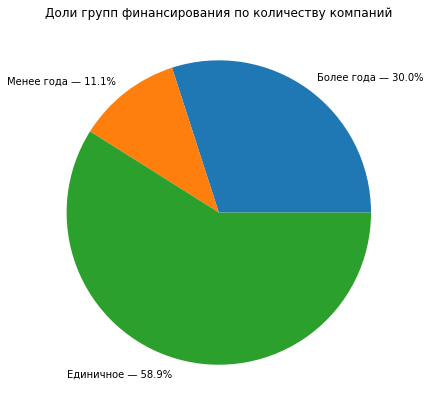

In [45]:
# Построим круговую диаграмму по количеству компаний
grouped = dfi['funding_type'].value_counts().reindex(['Более года', 'Менее года', 'Единичное'])
shares = grouped / grouped.sum() * 100

labels = [f'{name} — {share:.1f}%'
    for name, share in zip(grouped.index, shares)]

grouped.plot(
    kind='pie',
    title='Доли групп финансирования по количеству компаний',
    labels=labels,
    ylabel='',
    legend=False,
    figsize=(7, 7))

# Выводим график
plt.show()

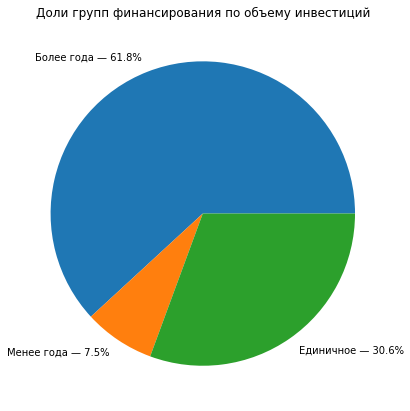

In [46]:
# Построим круговую диаграмму по объёму инвестиций
grouped = (
    dfi.groupby('funding_type')['funding_total_usd']
    .sum()
    .reindex(['Более года', 'Менее года', 'Единичное'])
)
shares = grouped / grouped.sum() * 100

labels = [f'{name} — {share:.1f}%'
    for name, share in zip(grouped.index, shares)]

grouped.plot(
    kind='pie',
    title='Доли групп финансирования по объему инвестиций',
    labels=labels,
    ylabel='',
    legend=False,
    figsize=(7, 7))

# Выводим график
plt.show()

Группа с финансированием «Более года» занимает 25% по количеству кампаний, но при этом почти 62% по объемам привлеченных инвестиций.<br>
Доли категории «Менее года» сопоставимы по количеству камапний и инвестициям.<br>
Компании с единичным финансированием составляют около 65% выборки, однако на них приходится лишь около 31% общего объема привлеченных инвестиций.

### 2.2 Выделение средних и нишевых сегментов рынка

Сегменты рынка (столбец `market`) разделены на три группы по числу компаний: сегменты с более чем 120 компаниями отнесены к массовым, от 35 до 120 включительно — к средним, менее 35 — к нишевым.

In [47]:
dfi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         38404 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                40907 non-null  object        
 6   country_code          40907 non-null  object        
 7   state_code            40907 non-null  object        
 8   region                40907 non-null  object        
 9   city                  40907 non-null  object        
 10  funding_rounds        40907 non-null  Int64         
 11  participants          27331 non-null  Int64         
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

В столбце market нет пропусков. Проверим лишние символы.

In [48]:
dfi['market'].unique()

array([' Education ', 'unknown', ' Business Services ', ' Social Media ',
       ' Hardware + Software ', ' Biotechnology ', ' Hardware + Software',
       ' Hospitality ', ' Enterprise Software ', ' Manufacturing ',
       'Finance', ' Finance ', ' Design ', ' Utilities ', ' Nonprofits ',
       ' Software ', ' Curated Web ', ' Health Care ', ' Education',
       ' Pharmaceuticals ', ' Health and Wellness ', ' Media ',
       ' Politics ', ' Clean Technology ', 'Manufacturing',
       ' Financial Services ', ' Consumer Electronics ', ' Web Hosting ',
       'E-Commerce', ' Automotive ', ' Local Businesses ', ' E-Commerce ',
       ' Medical ', ' Fashion ', ' Banking ', 'Security ', ' Publishing ',
       ' Networking ', ' Analytics ', ' Semiconductors ',
       ' Public Relations ', ' Jewelry ', ' Nanotechnology ', ' Travel ',
       ' Public Transportation ', 'Consulting ', ' Security ',
       ' Real Estate ', ' Consulting ', 'Environmental Innovation ',
       ' Retail ', ' Restaur

In [49]:
# Убираем лишние пробелы в названиях кампаний
dfi['market'] = dfi['market'].str.strip()

In [50]:
# Проверим. Удалены
dfi['market'].unique()

array(['Education', 'unknown', 'Business Services', 'Social Media',
       'Hardware + Software', 'Biotechnology', 'Hospitality',
       'Enterprise Software', 'Manufacturing', 'Finance', 'Design',
       'Utilities', 'Nonprofits', 'Software', 'Curated Web',
       'Health Care', 'Pharmaceuticals', 'Health and Wellness', 'Media',
       'Politics', 'Clean Technology', 'Financial Services',
       'Consumer Electronics', 'Web Hosting', 'E-Commerce', 'Automotive',
       'Local Businesses', 'Medical', 'Fashion', 'Banking', 'Security',
       'Publishing', 'Networking', 'Analytics', 'Semiconductors',
       'Public Relations', 'Jewelry', 'Nanotechnology', 'Travel',
       'Public Transportation', 'Consulting', 'Real Estate',
       'Environmental Innovation', 'Retail', 'Restaurants', 'Services',
       'Technology', 'Telecommunications', 'Information Technology',
       'Music', 'Advertising', 'Payments', 'Games', 'Mobile',
       'Consumer Goods', 'Medical Devices', 'Human Resources',
  

In [51]:
# Сколько сегментов входит в каждую категорию
segments = dfi['market'].value_counts()

mass_count = (segments > 120).sum()
mid_count = ((segments >= 35) & (segments <= 120)).sum()
niche_count = (segments < 35).sum()

print('Массовые:', mass_count)
print('Средние:', mid_count)
print('Нишевые:', niche_count)

Массовые: 49
Средние: 57
Нишевые: 289


In [52]:
# Сколько компаний входит в каждую категорию

mass_count_comp = segments[segments > 120].sum()
mid_count_comp = segments[(segments >= 35) & (segments <= 120)].sum()
niche_count_comp = segments[segments < 35].sum()

print('Массовые:', mass_count_comp)
print('Средние:', mid_count_comp)
print('Нишевые:', niche_count_comp)

Массовые: 36236
Средние: 3841
Нишевые: 830


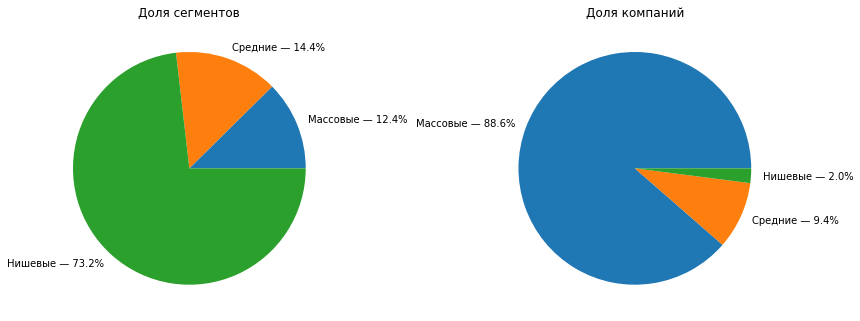

In [53]:
# Создаем Series с количеством сегментов каждой категории
categories = pd.Series({
    'Массовые': mass_count,
    'Средние': mid_count,
    'Нишевые': niche_count
})

# Создаем Series с количеством компаний в каждой категории
companies = pd.Series({
    'Массовые': mass_count_comp,
    'Средние': mid_count_comp,
    'Нишевые': niche_count_comp
})

# Формируем подписи с процентами для первой круговой диаграммы
labels_segments = [
    f'Массовые — {mass_count / categories.sum() * 100:.1f}%',
    f'Средние — {mid_count / categories.sum() * 100:.1f}%',
    f'Нишевые — {niche_count / categories.sum() * 100:.1f}%'
]

# Формируем подписи с процентами для второй круговой диаграммы
labels_companies = [
    f'Массовые — {mass_count_comp / companies.sum() * 100:.1f}%',
    f'Средние — {mid_count_comp / companies.sum() * 100:.1f}%',
    f'Нишевые — {niche_count_comp / companies.sum() * 100:.1f}%'
]

# Создаем одну область для вывода с двумя графиками рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Строим первую круговую диаграмму
categories.plot(
    kind='pie',                 
    ax=axes[0],                 # рисуем в левой части окна
    labels=labels_segments,     # добавляем подготовленные подписи
    ylabel=''                   
)

# Строим вторую круговую диаграмму
companies.plot(
    kind='pie',                 
    ax=axes[1],                 # рисуем в правой части окна
    labels=labels_companies,    # добавляем подготовленные подписи
    ylabel=''                   
)

# Добавляем заголовки к каждой диаграмме
axes[0].set_title('Доля сегментов')
axes[1].set_title('Доля компаний')

# Автоматически выравниваем расположение графиков
plt.tight_layout()

# Показываем оба графика
plt.show()

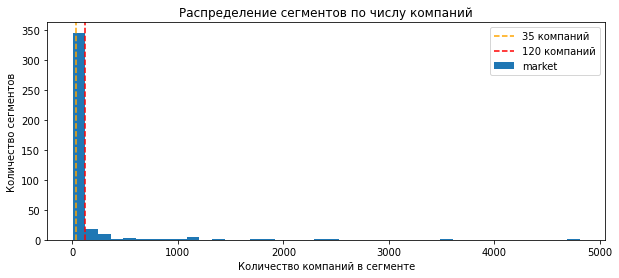

In [54]:
plt.figure(figsize=(10, 4))

segments.plot(kind='hist', bins=40)

plt.axvline(35, color='orange', linestyle='--', label='35 компаний')
plt.axvline(120, color='red', linestyle='--', label='120 компаний')

plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.title('Распределение сегментов по числу компаний')
plt.legend()

plt.show()

Большинство сегментов рынка являются нишевыми: в них работает небольшое число компаний. Массовых сегментов значительно меньше, а сегментов со средним количеством компаний немного больше, чем массовых.<br>
<br>
При этом почти 89% всех компаний сосредоточено в массовых сегментах, около 9% — в средних и лишь около 2% — в нишевых.<br>
<br>
Рынок стартапов состоит из большого количества небольших специализированных направлений, но основная часть компаний работает в нескольких наиболее популярных и развитых сегментах. 

В столбце `market` оставлены только массовые сегменты. Средние и нишевые сегменты объединены в общие категории `mid` и `niche` соответственно.

In [55]:
# Как часто встречаются сегменты компаний
segments = dfi['market'].value_counts()
segments

Software               4812
Biotechnology          3590
unknown                2503
Mobile                 2344
E-Commerce             1866
                       ... 
Animal Feed               1
Clinical Trials           1
Gold                      1
Space Travel              1
Online Reservations       1
Name: market, Length: 395, dtype: int64

In [56]:
# Функция для сегментации компаний
def segments_market(m):
    if segments[m] > 120:
        return m
    elif 35 <= segments[m] <= 120:
        return 'mid'
    else:
        return 'niche'

In [57]:
# Сегментируем кампании с помощью функции
dfi['market'] = dfi['market'].apply(segments_market)
dfi['market']

0        Education
1          unknown
2              mid
3        Education
4        Education
           ...    
49433      unknown
49434        niche
49435      unknown
49436      unknown
49437     Startups
Name: market, Length: 40907, dtype: object

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

In [58]:
# Посмотрим на основные статистики столбца
dfi['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Есть большой выброс в max, который не позволит корректно визуализировать и анализировать данные. 

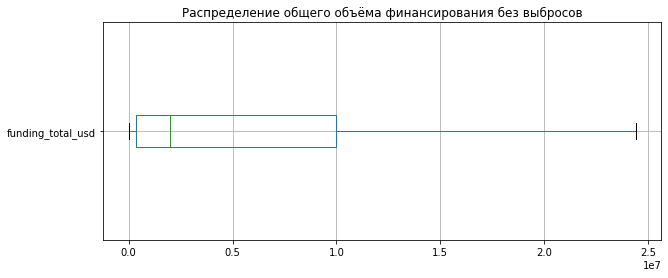

In [59]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 4))

# Строим диаграмму размаха значений в столбце funding_total_usd и скрываем выбросы
dfi.boxplot(column='funding_total_usd', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение общего объёма финансирования без выбросов')
plt.xlabel(' ')

# Выводим график
plt.show() 

Типичные значения общего финансирования находятся в интервале от 0 до 24 млн долларов. Распределение сильно смещено вправо и содержит крупные выбросы.

Компании с аномальным объёмом общего финансирования определены методом IQR отдельно по каждому сегменту (нишевые сегменты объединены в одну группу, средние — в другую).

In [60]:
dfi['market'].unique()

array(['Education', 'unknown', 'mid', 'Social Media',
       'Hardware + Software', 'Biotechnology', 'Hospitality',
       'Enterprise Software', 'Manufacturing', 'Finance', 'Design',
       'niche', 'Nonprofits', 'Software', 'Curated Web', 'Health Care',
       'Health and Wellness', 'Clean Technology', 'Web Hosting',
       'E-Commerce', 'Automotive', 'Medical', 'Fashion', 'Security',
       'Networking', 'Analytics', 'Semiconductors', 'Public Relations',
       'Travel', 'Consulting', 'Real Estate', 'Technology', 'Music',
       'Advertising', 'Games', 'Mobile', 'Internet', 'Sports',
       'Photography', 'News', 'Search', 'Messaging', 'Video',
       'Marketplaces', 'Entertainment', 'SaaS', 'Cloud Computing',
       'Big Data', 'Apps', 'Social Network Media', 'Startups'],
      dtype=object)

In [61]:
# Считаем первый квантиль
q1 = dfi.groupby('market')['funding_total_usd'].quantile(0.25)
q1

market
Advertising              500000.00
Analytics                500000.00
Apps                     100000.00
Automotive               265032.50
Big Data                 300000.00
Biotechnology           1500000.00
Clean Technology        1500000.00
Cloud Computing          585305.00
Consulting               125000.00
Curated Web              200000.00
Design                   160000.00
E-Commerce               226570.00
Education                185040.50
Enterprise Software     1000000.00
Entertainment            125000.00
Fashion                  153257.50
Finance                  500000.00
Games                    350000.00
Hardware + Software      752500.00
Health Care             1250000.00
Health and Wellness      323400.00
Hospitality              200000.00
Internet                 250000.00
Manufacturing            750000.00
Marketplaces              80943.25
Medical                  150000.00
Messaging                500000.00
Mobile                   300000.00
Music        

In [62]:
# Считаем третий квантиль
q3 = dfi.groupby('market')['funding_total_usd'].quantile(0.75)
q3

market
Advertising             11144998.00
Analytics               11079181.00
Apps                     2169575.00
Automotive              10000000.00
Big Data                 7000000.00
Biotechnology           22031670.50
Clean Technology        28196619.50
Cloud Computing         10000000.00
Consulting               5330000.00
Curated Web              4750000.00
Design                   5100000.00
E-Commerce               6457942.00
Education                4839456.00
Enterprise Software     15000000.00
Entertainment            7726236.50
Fashion                  7989844.50
Finance                 13454698.25
Games                    8100000.00
Hardware + Software     11168450.50
Health Care             27700000.00
Health and Wellness      7750000.00
Hospitality              7025000.00
Internet                 5000000.00
Manufacturing           13671551.00
Marketplaces             2032737.25
Medical                 10000000.00
Messaging                7631900.00
Mobile               

In [63]:
# Считаем размах
iqr = q3 - q1
iqr

market
Advertising             10644998.00
Analytics               10579181.00
Apps                     2069575.00
Automotive               9734967.50
Big Data                 6700000.00
Biotechnology           20531670.50
Clean Technology        26696619.50
Cloud Computing          9414695.00
Consulting               5205000.00
Curated Web              4550000.00
Design                   4940000.00
E-Commerce               6231372.00
Education                4654415.50
Enterprise Software     14000000.00
Entertainment            7601236.50
Fashion                  7836587.00
Finance                 12954698.25
Games                    7750000.00
Hardware + Software     10415950.50
Health Care             26450000.00
Health and Wellness      7426600.00
Hospitality              6825000.00
Internet                 4750000.00
Manufacturing           12921551.00
Marketplaces             1951794.00
Medical                  9850000.00
Messaging                7131900.00
Mobile               

In [64]:
# Считаем нижний порог
lower = q1 - 1.5 * iqr
lower

market
Advertising            -1.546750e+07
Analytics              -1.536877e+07
Apps                   -3.004362e+06
Automotive             -1.433742e+07
Big Data               -9.750000e+06
Biotechnology          -2.929751e+07
Clean Technology       -3.854493e+07
Cloud Computing        -1.353674e+07
Consulting             -7.682500e+06
Curated Web            -6.625000e+06
Design                 -7.250000e+06
E-Commerce             -9.120488e+06
Education              -6.796583e+06
Enterprise Software    -2.000000e+07
Entertainment          -1.127685e+07
Fashion                -1.160162e+07
Finance                -1.893205e+07
Games                  -1.127500e+07
Hardware + Software    -1.487143e+07
Health Care            -3.842500e+07
Health and Wellness    -1.081650e+07
Hospitality            -1.003750e+07
Internet               -6.875000e+06
Manufacturing          -1.863233e+07
Marketplaces           -2.846748e+06
Medical                -1.462500e+07
Messaging              -1.01978

Т.к. объем финансирования не может быть отрицательным, при поиске аномальных значений учитываем далее только верхнюю границу.

In [65]:
# Считаем верхний порог
upper = q3 + 1.5 * iqr
upper

market
Advertising             2.711250e+07
Analytics               2.694795e+07
Apps                    5.273938e+06
Automotive              2.460245e+07
Big Data                1.705000e+07
Biotechnology           5.282918e+07
Clean Technology        6.824155e+07
Cloud Computing         2.412204e+07
Consulting              1.313750e+07
Curated Web             1.157500e+07
Design                  1.251000e+07
E-Commerce              1.580500e+07
Education               1.182108e+07
Enterprise Software     3.600000e+07
Entertainment           1.912809e+07
Fashion                 1.974472e+07
Finance                 3.288675e+07
Games                   1.972500e+07
Hardware + Software     2.679238e+07
Health Care             6.737500e+07
Health and Wellness     1.888990e+07
Hospitality             1.726250e+07
Internet                1.212500e+07
Manufacturing           3.305388e+07
Marketplaces            4.960428e+06
Medical                 2.477500e+07
Messaging               1.83297

In [66]:
# Создаем новую колонку для отметок аномалий
dfi['anomaly'] = False

In [67]:
# Перебираем уникальные сегменты
for market_type in dfi['market'].unique():

    # Компании текущего сегмента
    filtered = dfi[dfi['market'] == market_type]

    # Помечаем компании с аномальным финансированием в сегменте
    dfi.loc[
    (dfi['market'] == market_type)
    & (dfi['funding_total_usd'] > upper[market_type]),
    'anomaly'
] = True

In [68]:
# Считаем доли сегментов с аномалиями
anomaly_share = (dfi.groupby('market')['anomaly'].mean() * 100).sort_values(ascending=False)

# Выводим ТОП-10
anomaly_share.head(10)

market
Real Estate        17.204301
Entertainment      16.666667
Consulting         16.618911
Search             16.494845
Cloud Computing    16.447368
Photography        16.176471
SaaS               16.176471
Technology         15.966387
Video              15.957447
niche              15.903614
Name: anomaly, dtype: float64

Наибольшая доля компаний с аномальным объёмом финансирования наблюдается в сегментах Real Estate — 17,2%, Entertainment — 16,7% и Consulting — 16,6%. Далее идут Search, Cloud Computing, Photography, SaaS, Technology и Video, где доля аномальных значений составляет примерно от 16,0% до 16,5%. В категорию niche также попало около 15,9% компаний с аномальным объёмом финансирования.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [69]:
# Проверяем по всем ли месяцам 2014 есть данные
dfi[dfi['mid_funding_at'].dt.year == 2014]['mid_funding_at'].dt.month.value_counts().sort_index()

1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Name: mid_funding_at, dtype: int64

Данные представлены за все месяцы 2014 года, но в декабре зафиксировано только 30 наблюдений, это значительно меньше значений остальных месяцев. Возможно, данные неполные, связаны с сезонностью или другими обстоятельствами.

In [70]:
# Исключим из датасета кампании с аномальным финансированием
dfi_nonanomaly = dfi[dfi['anomaly'] == False]
dfi_nonanomaly

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_type,anomaly
1,University of New Brunswick,http://www.unb.ca,NaN,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Менее года,False
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
7,Duke University,http://www.duke.edu,|Education|,Education,8700000.0,operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49430,Grid4C,http://grid4c.com,NaN,unknown,1500000.0,operating,ISR,unknown,ISR - Other,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
49433,RiverSilica,http://riversilica.com,NaN,unknown,1500000.0,operating,IND,unknown,Bangalore,Bangalore,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
49434,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,niche,9000000.0,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
49435,DigiByte,http://digibyte.co,NaN,unknown,250000.0,operating,USA,CA,Los Angeles,Santa Monica,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False


In [71]:
# Считаем число раундов в каждом году датасета
rounds_by_year = dfi_nonanomaly.groupby(
    dfi_nonanomaly['mid_funding_at'].dt.year
    )['funding_rounds'].sum()
rounds_by_year

mid_funding_at
1921.0        1
1960.0        2
1979.0        1
1982.0        3
1983.0        1
1984.0        2
1985.0        3
1987.0        2
1989.0        1
1990.0        1
1992.0        5
1993.0        1
1994.0        4
1995.0        9
1996.0        8
1997.0        5
1998.0       15
1999.0       43
2000.0      113
2001.0       66
2002.0       98
2003.0      125
2004.0      181
2005.0      948
2006.0     1849
2007.0     2842
2008.0     3663
2009.0     4617
2010.0     6136
2011.0     7578
2012.0     9707
2013.0    12880
2014.0     7122
Name: funding_rounds, dtype: Int64

In [72]:
# Собираем годы, где более 50 раундов
rounds_50 = rounds_by_year[rounds_by_year >= 50]
rounds_50

mid_funding_at
2000.0      113
2001.0       66
2002.0       98
2003.0      125
2004.0      181
2005.0      948
2006.0     1849
2007.0     2842
2008.0     3663
2009.0     4617
2010.0     6136
2011.0     7578
2012.0     9707
2013.0    12880
2014.0     7122
Name: funding_rounds, dtype: Int64

In [73]:
dfi_filtered_50 = dfi_nonanomaly[dfi_nonanomaly['mid_funding_at'].dt.year.isin(rounds_50.index)]
dfi_filtered_50

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_type,anomaly
1,University of New Brunswick,http://www.unb.ca,NaN,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Менее года,False
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
7,Duke University,http://www.duke.edu,|Education|,Education,8700000.0,operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49430,Grid4C,http://grid4c.com,NaN,unknown,1500000.0,operating,ISR,unknown,ISR - Other,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
49433,RiverSilica,http://riversilica.com,NaN,unknown,1500000.0,operating,IND,unknown,Bangalore,Bangalore,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
49434,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,niche,9000000.0,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False
49435,DigiByte,http://digibyte.co,NaN,unknown,250000.0,operating,USA,CA,Los Angeles,Santa Monica,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное,False


In [74]:
print(len(dfi_nonanomaly))
print(len(dfi_filtered_50))

35663
35588


После исключения аномалий рассчитано суммарное количество раундов финансирования по каждому году. Для дальнейшего анализа оставлены только годы, в которых было зафиксировано не менее 50 раундов финансирования.

In [75]:
# Переименовываю копию итогового датасета для удобства в работе
dff = dfi_filtered_50.copy()

### 3.3. Анализ типов финансирования по объёму и популярности

Сопоставлены суммарный объём и популярность (частота использования) разных типов финансирования, чтобы выделить типы с высокой частотой, но небольшим объёмом, и наоборот — редкие, но крупные по объёму.

In [76]:
# Соберем колонки видов финансирования в список
funding_cols = [
    'seed',
    'venture',
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'debt_financing',
    'angel',
    'grant',
    'private_equity',
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market',
    'product_crowdfunding'
]

In [77]:
# Посчитаем суммы по видам финансирования
dff[funding_cols].sum()

seed                    9.431332e+09
venture                 1.290922e+11
equity_crowdfunding     2.379606e+08
undisclosed             2.100352e+09
convertible_note        5.660394e+08
debt_financing          8.178153e+09
angel                   2.481264e+09
grant                   1.978849e+09
private_equity          4.843109e+09
post_ipo_equity         1.946452e+09
post_ipo_debt           2.867183e+08
secondary_market        4.528580e+07
product_crowdfunding    1.860939e+08
dtype: float64

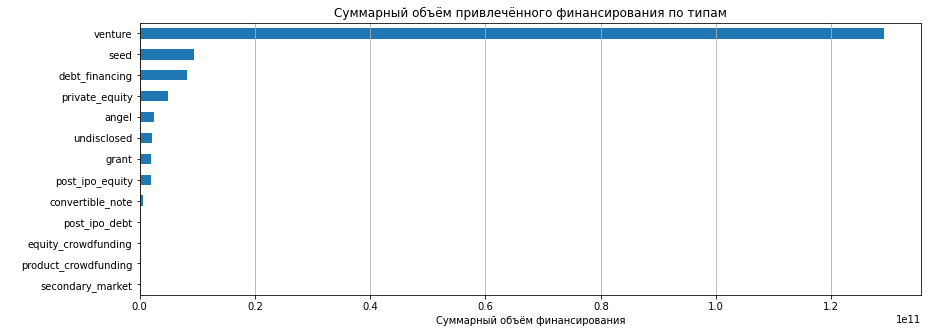

In [78]:
# Построим график распределения финансирования по типам
plt.figure(figsize=(14, 5))
dff[funding_cols].sum().sort_values(ascending=True).plot(
               kind='barh', 
               rot=0, 
               legend=False, 
               title='Суммарный объём привлечённого финансирования по типам'
)

# Настраиваем оформление графика
plt.xlabel('Суммарный объём финансирования')
plt.ylabel(' ')
# Добавляем сетку графика
plt.grid(axis='x')

# Выводим график
plt.show() 

In [79]:
# Считаем, сколько компаний использовали каждый тип финансирования
funding_popularity = (dff[funding_cols] > 0).sum()

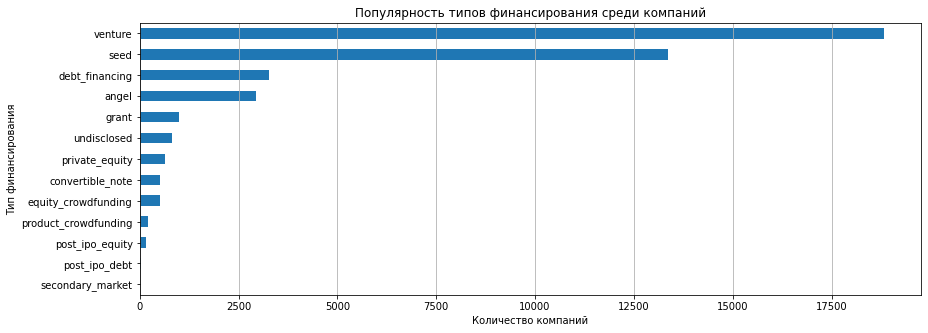

In [80]:
# Построим график популярности разных типов финансирования
plt.figure(figsize=(14, 5))

funding_popularity.sort_values(ascending=True).plot(
    kind='barh',
    legend=False,
    title='Популярность типов финансирования среди компаний'
)

plt.xlabel('Количество компаний')
plt.ylabel('Тип финансирования')
plt.grid(axis='x')

plt.show()

Наибольший суммарный объем привлеченного финансирования приходится на венчурные инвестиции (venture), которые значительно превосходят остальные типы. Наиболее популярными среди компаний также являются venture и seed — именно эти типы финансирования встречаются чаще всего. При этом такие типы, как grant, private_equity и debt_financing, привлекают значительные объемы средств при существенно меньшем числе компаний. А angel используется сравнительно часто, но характеризуется меньшими суммарными объемами финансирования.

In [81]:
# Собираем нужные колонки
returns_cols = [
    'seed',
    'venture',
    'equity_crowdfunding',
    'undisclosed',
    'convertible_note',
    'debt_financing',
    'angel',
    'grant',
    'private_equity',
    'post_ipo_equity',
    'post_ipo_debt',
    'secondary_market',
    'product_crowdfunding'
]

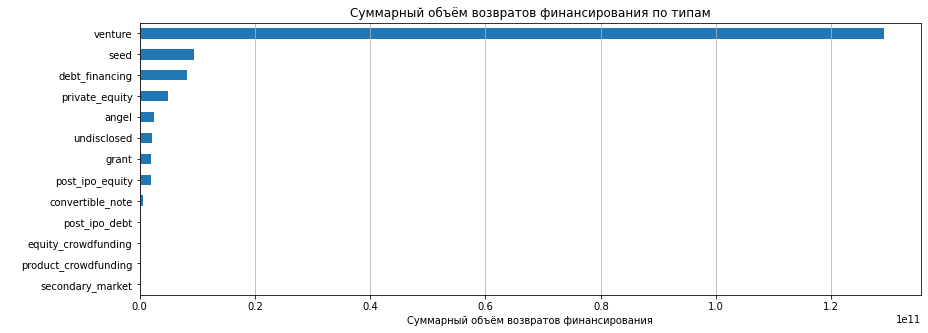

In [82]:
# Построим график распределения возвратов по типам
plt.figure(figsize=(14, 5))
dff[returns_cols].sum().sort_values(ascending=True).plot(
               kind='barh', 
               rot=0, 
               legend=False, 
               title='Суммарный объём возвратов финансирования по типам'
)

# Настраиваем оформление графика
plt.xlabel('Суммарный объём возвратов финансирования')
plt.ylabel(' ')
# Добавляем сетку графика
plt.grid(axis='x')

# Выводим график
plt.show()

Наибольший суммарный объём возвратов приходится на венчурное финансирование (venture), которое значительно превосходит остальные типы. Существенные объёмы возвратов также наблюдаются для seed, debt_financing и private_equity, однако они заметно уступают венчурным инвестициям. Для остальных типов финансирования объёмы возвратов значительно ниже, а по secondary_market, product_crowdfunding и equity_crowdfunding возвраты практически отсутствуют.

В целом распределение объёмов возвратов повторяет распределение объёмов привлечённого финансирования: наибольшие суммы как инвестиций, так и возвратов связаны с венчурным финансированием.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Для каждой компании рассчитан средний объём одного раунда финансирования; на графиках показана динамика типичного размера раунда и общего количества раундов по годам.

In [83]:
# Проверим, кникальны ли названия в строках датасета
dff['name'].is_unique

False

In [84]:
# Рассчитываем средний объем одного раунда финансирования для каждой компании
dff['avg_funding_round'] = (
    dff['funding_total_usd'] / dff['funding_rounds']
)
dff['avg_funding_round']

1             2000000.0
2             9000000.0
3        2566666.666667
4              540000.0
7             8700000.0
              ...      
49430         1500000.0
49433         1500000.0
49434         9000000.0
49435          250000.0
49437           11500.0
Name: avg_funding_round, Length: 35588, dtype: Float64

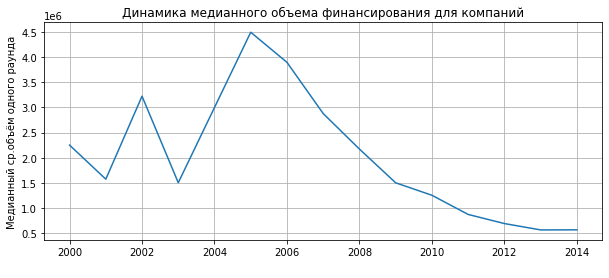

In [85]:
# Динамика медианного объема финансирования для компаний
plt.figure(figsize=(10, 4))
dff.groupby(dff['mid_funding_at'].dt.year)['avg_funding_round'].median().plot(
               kind='line', 
               rot=0, 
               legend=False, 
               title='Динамика медианного объема финансирования для компаний'
)

# Настраиваем оформление графика
plt.xlabel(' ')
plt.ylabel('Медианный ср.объём одного раунда')
# Добавляем сетку графика
plt.grid(True)

# Выводим график
plt.show()

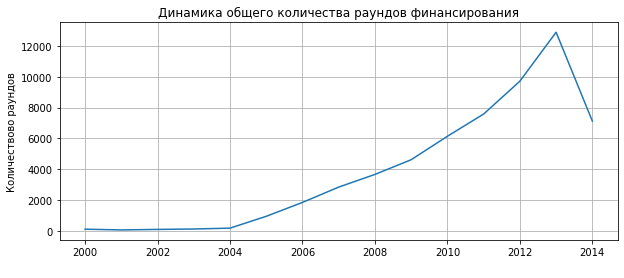

In [86]:
# Динамика общего количества раундов 
plt.figure(figsize=(10, 4))
dff.groupby(dff['mid_funding_at'].dt.year)['funding_rounds'].sum().plot(
               kind='line', 
               rot=0, 
               legend=False, 
               title='Динамика общего количества раундов финансирования'
)

# Настраиваем оформление графика
plt.xlabel(' ')
plt.ylabel('Количествово раундов')
# Добавляем сетку графика
plt.grid(True)

# Выводим график
plt.show()

До 2005–2006 годов типичный размер одного раунда финансирования в целом увеличивался, несмотря на отдельные колебания. После 2006 года наблюдается тенденция к его снижению. При этом общее количество раундов финансирования, наоборот, начинает быстро расти именно после 2005–2006 годов и достигает максимума к 2013 году.

После 2006 года инвестиционная активность рынка существенно возросла — раундов финансирования стало больше, но типичный объём одного раунда постепенно уменьшался.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Рассмотрены только массовые сегменты, показавшие рост суммарного финансирования в 2014 году по сравнению с 2013.

In [87]:
# Сводная таблица с суммарным общим финансированием и заполненными пропусками
pivot_funding = pd.pivot_table(dff,
                             index=dff['mid_funding_at'].dt.year,
                             columns='market',
                             values='funding_total_usd',
                             aggfunc="sum",
                             fill_value=0)
pivot_funding

market,Advertising,Analytics,Apps,Automotive,Big Data,Biotechnology,Clean Technology,Cloud Computing,Consulting,Curated Web,...,Software,Sports,Startups,Technology,Travel,Video,Web Hosting,mid,niche,unknown
mid_funding_at,,,,,,,,,,,,,,,,,,,,,
2000,14470000,14822803,0,0,0,0,0,11500000,4500000,1000000,...,31732640,0,0,0,50230,0,95343090,82440389,14600000,1839560
2001,8778321,0,0,0,0,0,0,0,0,305000,...,27811352,0,0,22160000,0,0,15000000,9441026,24020000,10160345
2002,24500000,7500000,0,0,0,0,34390435,0,0,4650000,...,101026395,200000,0,11000000,0,0,0,18885799,0,242132
2003,10500000,3840000,0,4530000,0,85531178,50352939,0,0,2550000,...,66086037,0,0,0,0,5000000,0,43238404,0,4155202
2004,6000000,3000000,0,0,0,97184859,50427954,0,0,27050000,...,140823795,0,0,1750000,10230000,14704000,27000000,54438160,0,10847977
2005,127196022,79014044,0,22500000,0,480063583,19420000,0,44862000,53450000,...,993076581,1882200,0,50728425,27830000,6470551,483332632,214407455,0,28384331
2006,299299458,139701311,1310600,12660000,0,903500543,131473889,9951809,23965548,164673698,...,1646868624,7000000,0,22791000,11700000,35171772,649959267,347522579,11180000,46049840
2007,556704331,98829000,0,37712601,7780000,1704078338,749711239,20354343,70346345,314704515,...,1686115571,16401580,0,180190209,13950000,85150644,361121449,503542893,44494637,35532468
2008,622673464,208077840,4300000,59478635,2452515,1716033000,3165808492,44375000,19061080,336500027,...,1365005648,9554790,5010387,277726238,54905631,37865177,781623731,550374758,22279331,45345010


In [88]:
# Создаем маску для отбора нужных сегментов по росту финансирования
mask_pivot = pivot_funding.loc[2014] > pivot_funding.loc[2013]
mask_pivot.head()

market
Advertising    False
Analytics      False
Apps            True
Automotive     False
Big Data        True
dtype: bool

In [89]:
# Оставим только те компании, где есть рост в 2014 году
mask_pivot[mask_pivot]

market
Apps             True
Big Data         True
Design           True
Internet         True
Manufacturing    True
Medical          True
Real Estate      True
SaaS             True
Startups         True
Technology       True
mid              True
niche            True
unknown          True
dtype: bool

In [90]:
# Получим список кампаний по индексам
name_list = mask_pivot[mask_pivot].index
name_list

Index(['Apps', 'Big Data', 'Design', 'Internet', 'Manufacturing', 'Medical',
       'Real Estate', 'SaaS', 'Startups', 'Technology', 'mid', 'niche',
       'unknown'],
      dtype='object', name='market')

In [91]:
# Цикл для исключения всех сегментов, кроме массового
mass_growth_segments = []

for name in name_list:
    if name not in ['niche', 'mid', 'unknown']:
        mass_growth_segments.append(name)

mass_growth_segments

['Apps',
 'Big Data',
 'Design',
 'Internet',
 'Manufacturing',
 'Medical',
 'Real Estate',
 'SaaS',
 'Startups',
 'Technology']

In [92]:
# Отфильтруем данные сводной таблицы толкьо по этим сегментам
pivot_mass_growth = pivot_funding[mass_growth_segments]
pivot_mass_growth

market,Apps,Big Data,Design,Internet,Manufacturing,Medical,Real Estate,SaaS,Startups,Technology
mid_funding_at,,,,,,,,,,
2000,0,0,0,10000000,56659310,24000000,2500000,0,0,0
2001,0,0,0,0,2368582,0,0,0,0,22160000
2002,0,0,0,1100000,0,0,5275000,2000000,0,11000000
2003,0,0,0,0,4269608,0,6292200,0,0,0
2004,0,0,0,10500000,3000000,0,0,0,0,1750000
2005,0,0,9300000,1775000,61770000,11090000,250000,5240000,0,50728425
2006,1310600,0,707000,5000,163957751,20250000,2080000,4791121,0,22791000
2007,0,7780000,10800000,4495379,147726051,2100000,33220000,14652595,0,180190209
2008,4300000,2452515,5944302,23412964,173054260,28812744,46613100,27226900,5010387,277726238


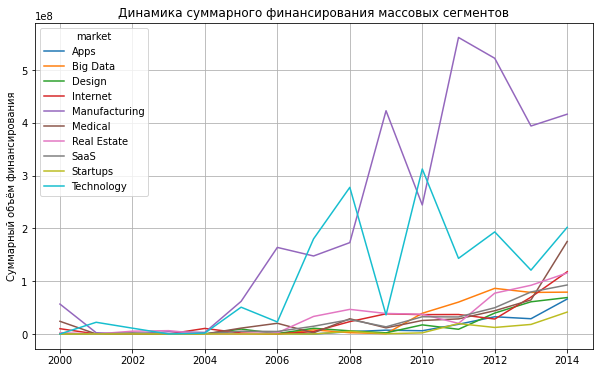

In [93]:
# Строим линемную диаграмму на основе отфильтрованной сводной таблицы
pivot_mass_growth.plot(figsize=(10, 6))

plt.title('Динамика суммарного финансирования массовых сегментов')
plt.xlabel(' ')
plt.ylabel('Суммарный объём финансирования')
plt.grid(True)

plt.show()

Среди массовых сегментов наиболее быстрый рост суммарного финансирования в 2014 году показывают Manufacturing и Technology. Но для сегмента Technology характерны значительные колебания объёмов финансирования, поэтому его рост нельзя назвать устойчивым. Сегмент Manufacturing после 2008 года демонстрирует высокий уровень финансирования и в целом сохраняет восходящую динамику, несмотря на отдельные спады. Уверенный рост в последние годы также показывают Medical Devices, Real Estate Media и Financial Services, хотя их объёмы финансирования заметно уступают лидерам.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчика интересует, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Для каждого года и вида финансирования рассчитаны нормированные значения возврата средств — доля возвращённых средств от предоставленных. Аномальные значения заменены на пропуски.

In [94]:
# Получим суммарные объемы инвестирования по годам 
# B оставим только нужные колонки с видами финансирования
dffg = dff.groupby(dff['mid_funding_at'].dt.year)[funding_cols].sum()
dffg

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
mid_funding_at,,,,,,,,,,,,,
2000,1.675914e+07,3.279622e+08,0.0,112202640.0,0.0,1.400000e+07,24086333.0,293114.0,0.000000e+00,3467747.0,0.0,7718867.0,0.0
2001,2.667675e+06,2.175191e+08,0.0,36596784.0,1500000.0,5.829217e+06,1000000.0,100000.0,0.000000e+00,0.0,0.0,0.0,0.0
2002,1.046519e+07,3.069406e+08,0.0,42323731.0,0.0,1.530967e+07,3000000.0,0.0,7.500000e+06,300000.0,0.0,0.0,0.0
2003,1.531836e+07,3.722344e+08,0.0,10280000.0,0.0,1.050000e+06,5629661.0,16850717.0,0.000000e+00,0.0,0.0,0.0,0.0
2004,1.810473e+07,6.641505e+08,0.0,62912359.0,0.0,3.081662e+07,11013741.0,10363600.0,0.000000e+00,0.0,0.0,0.0,0.0
2005,3.942520e+07,4.809711e+09,0.0,8871332.0,0.0,1.017207e+08,60914621.0,6266481.0,5.000000e+06,4796022.0,0.0,0.0,0.0
2006,6.679477e+07,9.020604e+09,933057.0,61545498.0,10702385.0,1.408484e+08,70756153.0,6147500.0,1.782024e+07,0.0,0.0,0.0,0.0
2007,1.922965e+08,1.206209e+10,0.0,109649902.0,14116788.0,2.086016e+08,201152441.0,34237779.0,1.533702e+08,12000000.0,0.0,0.0,0.0
2008,3.020030e+08,1.423473e+10,0.0,119920337.0,28600902.0,4.286221e+08,249299613.0,23485347.0,1.917563e+08,36000000.0,0.0,0.0,1000000.0


In [95]:
# Находим отношение значений значений в таблицах
returns_share = (dfr * 1_000_000) / (dffg + 1e-60)
returns_share

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.996471,0.168922,0.000000e+00,0.697042,0.000000e+00,0.618571,0.266956,0.0,0.000000e+00,2.710694e-01,0.000000,2.591054e-02,0.000000
2001,1.079592,0.107991,0.000000e+00,0.587483,6.666667e-03,0.770258,1.180000,0.0,0.000000e+00,4.600000e+65,0.000000,4.600000e+65,0.000000
2002,0.629707,0.682282,0.000000e+00,0.608878,2.000000e+64,0.223388,1.136667,0.0,2.013333e-01,1.133333e+00,0.000000,6.000000e+64,0.000000
2003,0.505276,0.628260,0.000000e+00,0.914397,1.000000e+64,1.038095,0.605720,0.0,1.620000e+66,2.110000e+66,0.000000,8.000000e+64,0.000000
2004,0.548476,0.837009,0.000000e+00,0.527559,1.000000e+64,0.439698,0.833504,0.0,2.190000e+66,3.380000e+66,0.000000,5.500000e+65,0.000000
2005,0.674695,0.546586,0.000000e+00,1.071992,2.000000e+64,0.344964,0.509894,0.0,4.800000e-01,7.318565e-01,0.000000,5.000000e+64,0.000000
2006,0.925372,0.343678,2.036317e-01,0.759438,1.663181e-01,0.803772,0.674853,0.0,9.354530e-01,2.058000e+67,0.000000,1.200000e+65,0.000000
2007,0.366153,0.297243,1.000000e+64,0.504971,2.280972e-01,0.602488,0.817837,0.0,5.790563e-01,2.030000e+00,0.000000,5.700000e+65,0.000000
2008,0.297083,0.190873,3.000000e+64,0.342060,5.978832e-02,0.927484,0.412476,0.0,6.799254e-01,2.341111e+00,0.000000,4.700000e+65,0.000000


<AxesSubplot:>

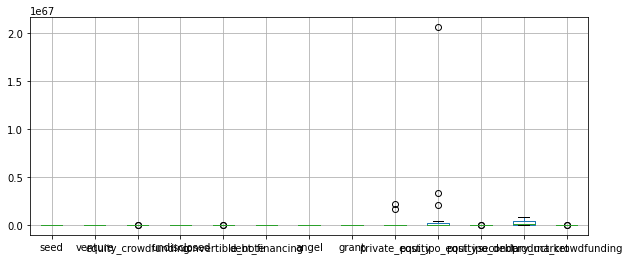

In [96]:
# Есть ли выбросы
returns_share.boxplot(figsize=(10, 4))

In [97]:
returns_share.describe()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
count,15.000000,15.000000,1.500000e+01,15.000000,1.500000e+01,15.000000,15.000000,15.0,1.500000e+01,1.500000e+01,15.000000,1.500000e+01,15.000000
mean,0.533780,0.392235,2.666667e+63,0.520753,4.000000e+63,0.622403,0.688456,0.0,2.540000e+65,1.768667e+66,0.143559,2.340000e+65,0.012332
std,0.290034,0.240756,7.988086e+63,0.262688,7.367884e+63,0.281261,0.282384,0.0,6.789046e+65,5.296237e+66,0.297196,2.721817e+65,0.023247
min,0.147911,0.107991,0.000000e+00,0.157879,0.000000e+00,0.223388,0.266956,0.0,0.000000e+00,2.673424e-01,0.000000,6.217617e-03,0.000000
25%,0.288080,0.194841,0.000000e+00,0.306314,4.972888e-02,0.442423,0.505386,0.0,5.295282e-01,6.994626e-01,0.000000,2.049352e-01,0.000000
50%,0.526648,0.315805,2.457796e-02,0.515938,6.726960e-02,0.505181,0.615945,0.0,6.799254e-01,1.353284e+00,0.000000,8.000000e+64,0.000000
75%,0.652201,0.587423,9.242673e-02,0.652960,5.000000e+63,0.787015,0.825671,0.0,9.319571e-01,2.300000e+65,0.115300,4.650000e+65,0.012481
max,1.079592,0.837009,3.000000e+64,1.071992,2.000000e+64,1.241740,1.180000,0.0,2.190000e+66,2.058000e+67,0.980645,8.100000e+65,0.068571


In [98]:
# Если нужно заполнить пропуски нулями
'''
mask = returns_share < 5
returns_share[mask].fillna(0)
'''

'\nmask = returns_share < 5\nreturns_share[mask].fillna(0)\n'

In [99]:
# Сохраняем таблицу
mask = returns_share < 5
returns_share = returns_share[mask]
returns_share

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.996471,0.168922,0.000000,0.697042,0.000000,0.618571,0.266956,0.0,0.000000,0.271069,0.000000,0.025911,0.000000
2001,1.079592,0.107991,0.000000,0.587483,0.006667,0.770258,1.180000,0.0,0.000000,NaN,0.000000,NaN,0.000000
2002,0.629707,0.682282,0.000000,0.608878,NaN,0.223388,1.136667,0.0,0.201333,1.133333,0.000000,NaN,0.000000
2003,0.505276,0.628260,0.000000,0.914397,NaN,1.038095,0.605720,0.0,NaN,NaN,0.000000,NaN,0.000000
2004,0.548476,0.837009,0.000000,0.527559,NaN,0.439698,0.833504,0.0,NaN,NaN,0.000000,NaN,0.000000
2005,0.674695,0.546586,0.000000,1.071992,NaN,0.344964,0.509894,0.0,0.480000,0.731857,0.000000,NaN,0.000000
2006,0.925372,0.343678,0.203632,0.759438,0.166318,0.803772,0.674853,0.0,0.935453,NaN,0.000000,NaN,0.000000
2007,0.366153,0.297243,NaN,0.504971,0.228097,0.602488,0.817837,0.0,0.579056,2.030000,0.000000,NaN,0.000000
2008,0.297083,0.190873,NaN,0.342060,0.059788,0.927484,0.412476,0.0,0.679925,2.341111,0.000000,NaN,0.000000


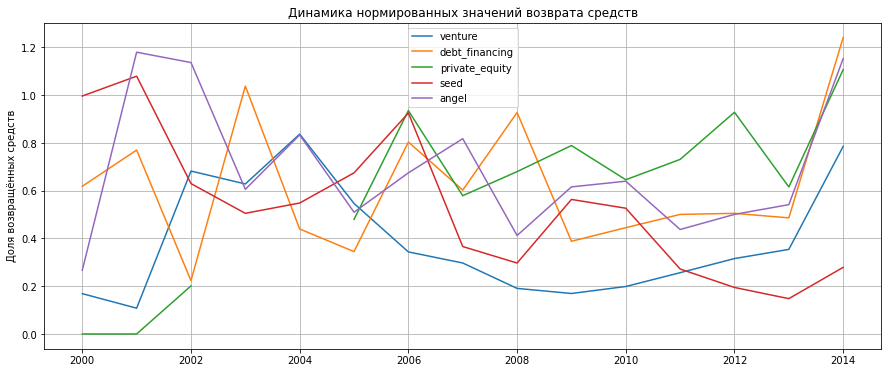

In [100]:
# Строим линеный график
returns_share[
    [
        'venture',
        'debt_financing',
        'private_equity',
        'seed',
        'angel'
    ]
].plot(figsize=(15, 6))

plt.title('Динамика нормированных значений возврата средств')
plt.xlabel(' ')
plt.ylabel('Доля возвращённых средств')
plt.grid(True)

plt.show()

Самый стабильный рост к концу рассматриваемого периода показывают private_equity и debt_financing. Венчурное финансирование также показывает положительную динамику, но менее явную. Для seed и angel характерны значительные колебания значений, поэтому их рост нельзя назвать устойчивым.


## Шаг 5. Итоговый вывод и рекомендации

В качестве наиболее перспективного направления для инвестиций в 2015 году можно рекомендовать массовые технологические сегменты, которые к 2014 году показали заметный рост общего объёма финансирования. Наиболее уверенно выглядели сегменты, связанные с производственными технологиями, технологиями в целом, медицинскими устройствами и прямыми инвестициями в развивающиеся компании.<br>
<br>
Основным типом финансирования можно считать private equity. По результатам анализа этот тип показывает один из наиболее устойчивых уровней возврата средств и положительную динамику к концу изученного периода. В качестве альтернативы можно рассматривать debt financing, но его показатели менялись менее равномерно.<br>
<br>
В проекте были подготовлены данные для анализа, изучены объёмы финансирования по годам, сегментам рынка и типам инвестиций, рассчитан средний размер одного раунда финансирования, проанализирована активность инвестиционного рынка и оценена доля возвращённых средств для разных типов финансирования. Для корректности расчётов были обработаны аномальные значения, возникавшие при делении на практически нулевой объём финансирования.<br>
<br>
Анализ показал, что после 2006 года количество инвестиционных раундов заметно выросло, при этом типичный размер одного раунда постепенно снижался. Это говорит о том, что рынок стал активнее за счёт увеличения числа сделок, а не их среднего размера. Одновременно часть массовых сегментов продолжала наращивать общий объём привлекаемого финансирования, что указывает на сохранение интереса инвесторов к этим направлениям.<br>
<br>
В целом результаты анализа хорошо согласуются между собой. Рост числа раундов и увеличение объёмов финансирования в отдельных сегментах подтверждают расширение рынка, а анализ возврата средств позволяет выделить типы финансирования, которые выглядели наиболее привлекательными с точки зрения эффективности. 